# Homework 11 - Chapter 16

- Due Date: Friday, April 24th no later than 11:59 p.m.
- Partner Information: You may complete this assignment individually or with exactly one classmate.
- Submission Instructions (working alone): Upload your solution, entitled **YourFirstName-YourLastName-Homework11.ipynb** to the 
Canvas Homework 11 Dropbox.
- Submission Instructions (working with one classmate): Upload your solution, entitled 
**YourFirstName-YourLastName-PartnerFirstName-PartnerLastName-Homework11.ipynb** to the Canvas Homework 11 Dropbox. Note: If you 
work with a partner, only one person needs to submit a solution. If you both submit a solution, the submission that will be graded is the one 
from the partner whose last name comes alphabetically first.
- Deadline Reminder: Once the submission deadline passes, Canvas will no longer accept your submission and you will no longer be able to earn credit. 
Thus, if you are not able to fully complete the assignment, submit whatever you have before the deadline so that partial credit can be earned.

## Starting Code

In [34]:
from datascience import *
import matplotlib.pyplot as plots
import numpy as np
%matplotlib inline

Download the file [cricket_chirps.csv]() into the same directory as this Jupyter notebook.

In [35]:
# Place the csv file in the same directory as your solution
chirps = Table().read_table("cricket_chirps.csv")
chirps.show(5)

Temperature,Chirps,Humidity_%,Wind_Speed_mph,Barometric_Pressure_hPa,Time_of_Day,Weather_Condition,Moon_Phase
88.6,19,60,1.3,1008.4,Dusk,Clear,Waxing Crescent
71.6,16,65,0.4,1013.6,Dusk,Overcast,New Moon
93.3,22,54.3,4.8,1005.7,Evening,Partly Cloudy,Full Moon
84.3,17,61.4,6.6,1009.9,Night,Partly Cloudy,Full Moon
80.6,19,69.4,1.6,1017.6,Dusk,Clear,Waning Gibbous


## Question 1a - 3 Points

To better utilize the vast amounts of data that are being generated, the number of Montana State professors who either are data scientists or who collaborate with data scientists has increased rapidly in recent years.  For example, Dr. Cascade Tuholske in Earth Sciences conducts research and teaches courses that involve data science.  In the School of Computing, Dr. Fasy, Dr. Nazemi and Dr. Reinhold all have research programs that involve data.  One common data science application is to better understand our natural world.

You have been selected to work on a study that analyzes how different variables affect the chirp rate of crickets. The researchers believe a linear relationship exists between temperature and chirp rate, but need your help determining whether it is statistically meaningful or simply the result of random chance. 

First, convert the temperature to standard units. Bootstrap the sample 5000 times and calculate the slope of the regression line each time. Then, create a histogram of the bootstrapped slopes with 10 bins. Plot a 99% confidence interval as a yellow bar along the x-axis (at y=0), and mark the observed slope as a red dot on top of the yellow bar.

In [36]:
def standard_units(numbers):
    "Convert any array of numbers to standard units."
    return (numbers - np.mean(numbers))/np.std(numbers)    

def correlation(t, label_x, label_y):
    "Calculate r"
    return np.mean(standard_units(t.column(label_x))*standard_units(t.column(label_y)))

def slope(t, label_x, label_y):
    "Calculate m of y = mx + b"
    r = correlation(t, label_x, label_y)
    return r*np.std(t.column(label_y))/np.std(t.column(label_x))

def one_bootstrap_slope(table, x_column, y_column):
    bootstrap_sample = table.sample()
    return slope(bootstrap_sample, x_column, y_column)

def many_bootstrap_slopes(how_many, table, x_column, y_column):
    slopes = make_array()
    for _ in np.arange(how_many):
        slopes = np.append(slopes, one_bootstrap_slope(table, x_column, y_column))
    return slopes


Observed slope: 1.31
Left = 1.22155531029 , Right = 1.39929317212


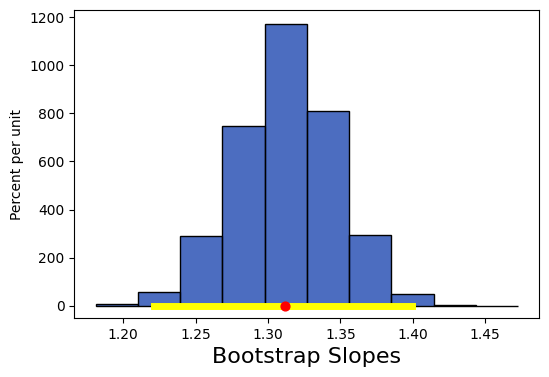

In [41]:
chirps = chirps.with_columns(
    'Standardized Temperature',  standard_units(chirps.column('Temperature')), 
)

slopes = many_bootstrap_slopes(5000, chirps, "Standardized Temperature", "Chirps")

observed_slope = slope(chirps, "Standardized Temperature", "Chirps")
print(f"Observed slope: {observed_slope:.2f}")

left = percentile(0.5, slopes)
right = percentile(99.5, slopes)
print("Left =", left, ", Right =", right)

Table().with_column("Bootstrap Slopes", slopes).hist(bins=10)
plots.plot([left, right], [0,0], color="yellow", lw=5);
plots.scatter(observed_slope, 0, color="r", zorder=4, s=40)
plots.ylim(-.5)
plots.show()



## Question 1b - 1 Point

Create a conclusion for the researchers if their Null Hypothesis was "The slope of the true relationship between temperature and chirps is 0."

**Answer -** Based on our findings above, we can reject the null hypothesis. The 99% confidence interval for the slope does not include 0. This suggests that there is a statistically significant positive relationship between temperature and chirp rate. We are 99% confident that the true slope lies between 1.23 and 1.40.

## Question 2a - 3 Points

The researchers want to use the model you created to estimate the number of chirps when the temperature is 50 degrees. Bootstrap the sample 5000 times, generating a prediction each time. Use this to create a 99% confidence interval. Then, print the predicted number of chirps in the following format where d is a digit:   

*Predicted Chirps When 50 Degrees: dd.dd  
99% Confidence Interval: [dd.dd, dd.dd]*

In [38]:
def intercept(t, label_x, label_y):
    "Calculate b of y = mx + b"
    return np.mean(t.column(label_y)) - slope(t, label_x, label_y)*np.mean(t.column(label_x))

def fitted_value(table, x, y, given_x):
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * given_x  + b

def one_bootstrap_prediction(table, x_column, y_column, x_to_predict):
    bootstrap_sample = table.sample()
    return fitted_value(bootstrap_sample, x_column, y_column, x_to_predict)

def many_bootstrap_predictions(how_many, table, x_column, y_column, x_to_predict):
    predictions = make_array()
    for _ in np.arange(how_many):
        predictions = np.append(predictions, one_bootstrap_prediction(table, x_column, y_column, x_to_predict))
    return predictions

In [39]:
temperature_to_predict = 50
chirps_at_50 = many_bootstrap_predictions(5000, chirps, "Temperature", "Chirps", temperature_to_predict)

prediction_at_50 = fitted_value(chirps, "Temperature", "Chirps", 50)
print(f"Predicted Chirps When 50 Degrees: {prediction_at_50:.2f}")

left = percentile(0.5, chirps_at_50)
right = percentile(99.5, chirps_at_50)
print(f"99% Confidence Interval: [{left:.2f}, {right:.2f}]")

Predicted Chirps When 50 Degrees: 13.14
99% Confidence Interval: [12.88, 13.40]


## Question 2b - 1 Point

Discuss any concerns that a data scientist might have about using the model to 
predict the number of chirps when the temperature is 50 degrees.

**Answer -**

## Question 3 - 2 Points

Develop an insightful visualization that uses the provided csv file, Chapter 16 knowledge, and any other data science knowledge that you have previously learned. Explain your visualization and what makes it insightful.

In [ ]:
# Place answer here.